<a href="https://colab.research.google.com/github/alimoorreza/CS181-fall26-notes/blob/main/day08_popular_cnn2_alexnet_dissection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS181: Computer Vision, Fall 2026

Thursday, September 17, 2026

📆 [Course Schedule](https://analytics.drake.edu/~reza/teaching/cs181_fall26/cs181_schedule.html) | 📜 [Syllabus](https://analytics.drake.edu/~reza/teaching/cs181_fall26/cs181_syllabus_fall26.pdf)


In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


![MLP architecture](https://raw.githubusercontent.com/alimoorreza/CS181-fall26-notes/main/images/alexnet.drawio.png)


##**Utility functions**
- Load the mapping between the **class indices and class names** for the 1,000 ImageNet categories.
- Display the **top-5 or top-10 predicted classes** from the 1,000 ImageNet categories.

In [ ]:
import torch
import torch.nn as nn
import torchvision
from torchvision import models, transforms, datasets

import sys
import os
import scipy.io

import json
import PIL
import numpy as np
import matplotlib.pyplot as plt

import requests
url = "https://analytics.drake.edu/~reza/teaching/cs181_fall26/datasets/imagenet_1000_classes.json"

response = requests.get(url)
response.raise_for_status()
label_map = response.json()
print(label_map)

def display_prediction(output_prob, label_map, how_many=10):
    print(f"label map: {label_map}")
    '''
    topk          = torch.topk(output_prob, k=how_many)
    topk_prob     = topk.values[0]
    topk_indices  = topk.indices[0]
    '''

    topk            = torch.topk(output_prob, k=how_many, dim=1)
    topk_prob       = topk.values[0]
    topk_indices    = topk.indices[0]


    if device == 'cuda':
        topk_indices  = topk_indices.data.cpu().numpy()
    else:
        topk_indices  = topk_indices.data.numpy()

    print(f"top{how_many}_classes are as follow: \n{topk_indices}")
    labels        = "{:75s}".format("predicted label")
    prob          = "{}".format("probability")
    print("\n{:75s}".format("--------------------------------------------------------------------------------------\n"), labels, prob,"\n{:75s}".format("--------------------------------------------------------------------------------------"))

    for i in range(how_many):
        labels  = label_map[str(topk_indices[i])]
        labels  = "{:75s}".format(labels)
        prob    = "{:.4f}".format(float(topk_prob[i]))
        print(labels, prob)

    print("{:75s}".format("--------------------------------------------------------------------------------------"))


# util function:
def get_imagenet_mean_std_normalized():
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    return mean, std


{'0': 'tench, Tinca tinca', '1': 'goldfish, Carassius auratus', '2': 'great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias', '3': 'tiger shark, Galeocerdo cuvieri', '4': 'hammerhead, hammerhead shark', '5': 'electric ray, crampfish, numbfish, torpedo', '6': 'stingray', '7': 'cock', '8': 'hen', '9': 'ostrich, Struthio camelus', '10': 'brambling, Fringilla montifringilla', '11': 'goldfinch, Carduelis carduelis', '12': 'house finch, linnet, Carpodacus mexicanus', '13': 'junco, snowbird', '14': 'indigo bunting, indigo finch, indigo bird, Passerina cyanea', '15': 'robin, American robin, Turdus migratorius', '16': 'bulbul', '17': 'jay', '18': 'magpie', '19': 'chickadee', '20': 'water ouzel, dipper', '21': 'kite', '22': 'bald eagle, American eagle, Haliaeetus leucocephalus', '23': 'vulture', '24': 'great grey owl, great gray owl, Strix nebulosa', '25': 'European fire salamander, Salamandra salamandra', '26': 'common newt, Triturus vulgaris', '27': 'eft', '28': '

# **Creating AlexNet network architecture**
> ## **Loading model's pretrained weights from PyTorch library**

In [ ]:
# You can give any name to your new network, e.g., AlexNet.
# You should load the pretrained AlexNet model from torchvision.models.
# This model was trained on over a million real-world images from ImageNet.


class AlexNet(nn.Module):

    def __init__(self, num_classes, pretrained=True):

        super(AlexNet, self).__init__()

        # download PyTorch's own implementation of AlexNet model trained on ImageNet dataset
        net             = models.alexnet(pretrained=True)


        # retained weightes for convolutional, pooling, linear layers from AlexNet
        self.features   = net.features
        self.avgpool    = net.avgpool
        self.classifier = net.classifier

        # IMPORTANT: "If you need to fine-tune this network for your own dataset,
        # the simplest modification is to replace the last layer in self.classifier with
        # the updated AlexNet has the desired number of output classes: 'num_classes'
        # self.classifier[-1] = nn.Linear(4096, num_classes) # only this last layer's weights will be trained from scratch


    def forward(self, x):

        print("Forward pass (AlexNet): shape of input: ", x.shape)
        x = self.features(x)
        print("Forward pass (AlexNet): output shape (self.features): ", x.shape)
        x = self.avgpool(x)
        print("Forward pass (AlexNet): output shape (self.avgpool): ", x.shape)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        print("Forward pass (AlexNet): output shape (self.classifier): ", x.shape)
        return x


In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"device={device}")
number_of_classes = 1000
model = AlexNet(number_of_classes)
model.to(device)

device=cuda


/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

# **Doing single forward pass on AlexNet using a sample image**

### **Run the pretrained model on a random image to test its classification ability**
> I have uploaded the images of `cat,` `dog,` and `bike` to Blackboard.

> You can download those images and upload them to your workspace. Alternatively, you can download random images of a `cat,` `dog,` or `any other class of your choice` and test them using AlexNet.


[width, height] of the image: [800, 534]


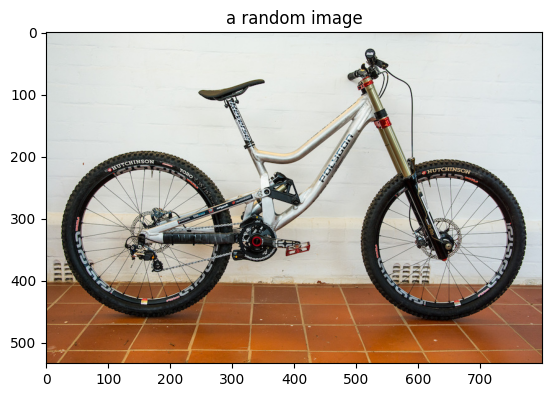

In [ ]:
TEST_IMAGE_DIR  = '/content/drive/MyDrive/cs181_fall26/module_3_classification/images/'
image_name_list = ['random_dog1.jpg',
                   'random_dog2.jpg',
                   'random_cat1.jpg',
                   'random_cat2.jpg',
                   'random_bike1.jpg'
                   ]

img_index       = 4
img_name        = TEST_IMAGE_DIR + '/' + image_name_list[img_index]
img             = PIL.Image.open(img_name)
print(f"[width, height] of the image: [{img.size[0]}, {img.size[1]}]")
plt.imshow(img)
plt.title("a random image")
plt.show()


##**Transform the image by resizing it**

- You can resize each image with the given HEIGHT and WIDTH using `torchvision.transform` operation


In [ ]:
from torchvision import transforms

TEST_IMAGE_SIZE_W   = 227
TEST_IMAGE_SIZE_H   = 227

# You need to normalize each image with the given mean and standard deviation before doing the forward-pass on these networks.
transform = transforms.Compose([
    transforms.Resize((TEST_IMAGE_SIZE_W, TEST_IMAGE_SIZE_H)),
    transforms.ToTensor()
])

img_tensor          = transform(img).unsqueeze(0).to(device)
print(f"Convert the image into PyTorch tensor after normalization: ...")
print(f"image tensor shape: {img_tensor.shape}") # [HOW_MANY_TENSORS, CHANNEL_SIZE, HEIGHT, WIDTH]
print(f"{"HOW_MANY_TENSORS:":<20} {img_tensor.shape[0]}")
print(f"{"CHANNEL_SIZE:":<20} {img_tensor.shape[1]}")
print(f"{"HEIGHT_SIZE:":<20} {img_tensor.shape[2]}")
print(f"{"WIDTH_SIZE:":<20} {img_tensor.shape[3]}")
print(f"Summary: [how_many, channel, height, width] of the image tensor: {img_tensor.shape[0]}x{img_tensor.shape[1]}x{img_tensor.shape[2]}x{img_tensor.shape[3]}")



Convert the image into PyTorch tensor after normalization: ...
image tensor shape: torch.Size([1, 3, 227, 227])
HOW_MANY_TENSORS:    1
CHANNEL_SIZE:        3
HEIGHT_SIZE:         227
WIDTH_SIZE:          227
Summary: [how_many, channel, height, width] of the image tensor: 1x3x227x227


### **Show the transformed image (for verification)**

shape: torch.Size([227, 227, 3])


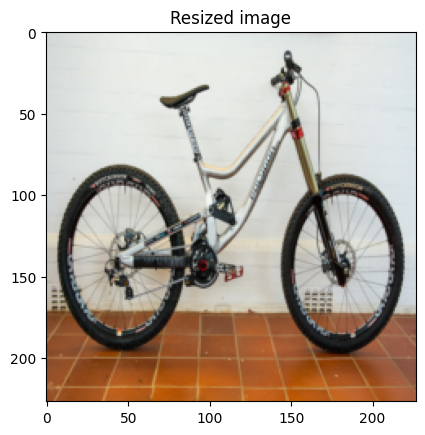

In [ ]:
transformed_back_img = img_tensor.squeeze(0).cpu()
transformed_back_img = transformed_back_img.permute(1, 2, 0)
print(f"shape: {transformed_back_img.shape}")
plt.imshow(transformed_back_img.data)
plt.title("Resized image")
plt.show()


##**Transform the image by resizing + normalizing it with ImageNet mean**

- CNN architectures such as AlexNet, VGGNet, and ResNet has been pre-trained using the ImageNet dataset.
- You need to normalize each image with the given mean and standard deviation before doing the forward-pass on these networks.
- You can compose resize and normalize operations together using `torchvision.transform` operation



In [ ]:
imagenet_mean, imagenet_std  = get_imagenet_mean_std_normalized()
print(f"ImageNet: mean: {imagenet_mean}, std: {imagenet_std}")

TEST_IMAGE_SIZE_W   = 227
TEST_IMAGE_SIZE_H   = 227

# CNN architectures such as AlexNet, VGGNet, and ResNet has been pre-trained using the ImageNet dataset.
# You need to normalize each image with the given mean and standard deviation before doing the forward-pass on these networks.
transform = transforms.Compose([
    transforms.Resize((TEST_IMAGE_SIZE_W, TEST_IMAGE_SIZE_H)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std) # ImageNet: mean (R, G, B) and standard deviation (R, G, B)
])

img_tensor          = transform(img).unsqueeze(0).to(device)
print(f"Convert the image into PyTorch tensor after normalization: ...")
print(f"image tensor shape: {img_tensor.shape}") # [HOW_MANY_TENSORS, CHANNEL_SIZE, HEIGHT, WIDTH]
print(f"{"HOW_MANY_TENSORS:":<20} {img_tensor.shape[0]}")
print(f"{"CHANNEL_SIZE:":<20} {img_tensor.shape[1]}")
print(f"{"HEIGHT_SIZE:":<20} {img_tensor.shape[2]}")
print(f"{"WIDTH_SIZE:":<20} {img_tensor.shape[3]}")
print(f"Summary: [how_many, channel, height, width] of the image tensor: {img_tensor.shape[0]}x{img_tensor.shape[1]}x{img_tensor.shape[2]}x{img_tensor.shape[3]}")



ImageNet: mean: [0.485, 0.456, 0.406], std: [0.229, 0.224, 0.225]
Convert the image into PyTorch tensor after normalization: ...
image tensor shape: torch.Size([1, 3, 227, 227])
HOW_MANY_TENSORS:    1
CHANNEL_SIZE:        3
HEIGHT_SIZE:         227
WIDTH_SIZE:          227
Summary: [how_many, channel, height, width] of the image tensor: 1x3x227x227


### **Show the transformed image (for verification)**

> PLEASE NOTE: Each pixel value has **changed after normalization**. There is now a stark contrast in the pixel values.

shape: torch.Size([227, 227, 3])


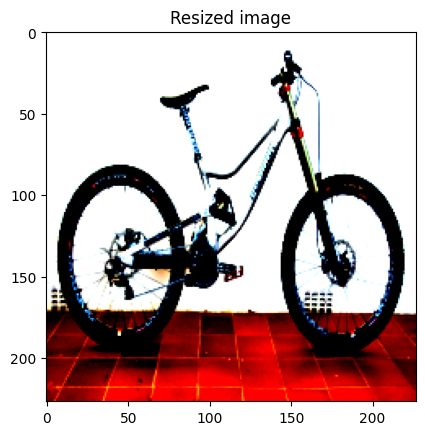

In [ ]:
transformed_back_img = img_tensor.squeeze(0).cpu()
transformed_back_img = transformed_back_img.permute(1, 2, 0)
print(f"shape: {transformed_back_img.shape}")
plt.imshow(transformed_back_img.data)
plt.title("Resized image")
plt.show()


## **Perform a forward pass of the input volume through your AlexNet.**


In [ ]:
raw_output          = model(img_tensor)
output_prob         = torch.softmax(raw_output, dim=1)
output_prob_numpy   = output_prob.data.cpu().numpy()[0]


Forward pass (AlexNet): shape of input:  torch.Size([1, 3, 227, 227])
Forward pass (AlexNet): output shape (self.features):  torch.Size([1, 256, 6, 6])
Forward pass (AlexNet): output shape (self.avgpool):  torch.Size([1, 256, 6, 6])
Forward pass (AlexNet): output shape (self.classifier):  torch.Size([1, 1000])


In [ ]:
print(f"Sum of all predicted probabilities: {np.sum(output_prob_numpy)}")
print(f"Probability of class-0: {output_prob_numpy[0]}")

Sum of all predicted probabilities: 1.0
Probability of class-0: 3.546253221631268e-11


### **Identifying the predicted label from the list of 1,000 predefined ImageNet classes.**
- Our forward pass of the input volume through AlexNet will produce a prediction corresponding to one of these 1,000 classes. We need to map the predicted class index to the appropriate ImageNet class name.**

label map: {'0': 'tench, Tinca tinca', '1': 'goldfish, Carassius auratus', '2': 'great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias', '3': 'tiger shark, Galeocerdo cuvieri', '4': 'hammerhead, hammerhead shark', '5': 'electric ray, crampfish, numbfish, torpedo', '6': 'stingray', '7': 'cock', '8': 'hen', '9': 'ostrich, Struthio camelus', '10': 'brambling, Fringilla montifringilla', '11': 'goldfinch, Carduelis carduelis', '12': 'house finch, linnet, Carpodacus mexicanus', '13': 'junco, snowbird', '14': 'indigo bunting, indigo finch, indigo bird, Passerina cyanea', '15': 'robin, American robin, Turdus migratorius', '16': 'bulbul', '17': 'jay', '18': 'magpie', '19': 'chickadee', '20': 'water ouzel, dipper', '21': 'kite', '22': 'bald eagle, American eagle, Haliaeetus leucocephalus', '23': 'vulture', '24': 'great grey owl, great gray owl, Strix nebulosa', '25': 'European fire salamander, Salamandra salamandra', '26': 'common newt, Triturus vulgaris', '27': 'ef

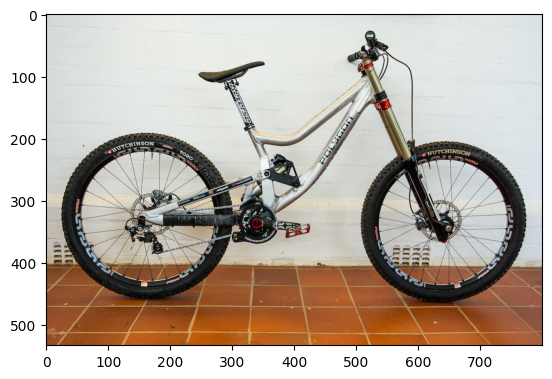

In [ ]:
display_prediction(output_prob, label_map, how_many=10)
plt.imshow(img)

##**To summarize**
- **you need to do the following steps to pass an input through a pretrained model like AlexNet and observe the classification label with probabilities as follows:**

/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


input image.shape=torch.Size([1, 3, 227, 227])
Forward pass (AlexNet): shape of input:  torch.Size([1, 3, 227, 227])
Forward pass (AlexNet): output shape (self.features):  torch.Size([1, 256, 6, 6])
Forward pass (AlexNet): output shape (self.avgpool):  torch.Size([1, 256, 6, 6])
Forward pass (AlexNet): output shape (self.classifier):  torch.Size([1, 1000])
label map: {'0': 'tench, Tinca tinca', '1': 'goldfish, Carassius auratus', '2': 'great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias', '3': 'tiger shark, Galeocerdo cuvieri', '4': 'hammerhead, hammerhead shark', '5': 'electric ray, crampfish, numbfish, torpedo', '6': 'stingray', '7': 'cock', '8': 'hen', '9': 'ostrich, Struthio camelus', '10': 'brambling, Fringilla montifringilla', '11': 'goldfinch, Carduelis carduelis', '12': 'house finch, linnet, Carpodacus mexicanus', '13': 'junco, snowbird', '14': 'indigo bunting, indigo finch, indigo bird, Passerina cyanea', '15': 'robin, American robin, Turdus mig

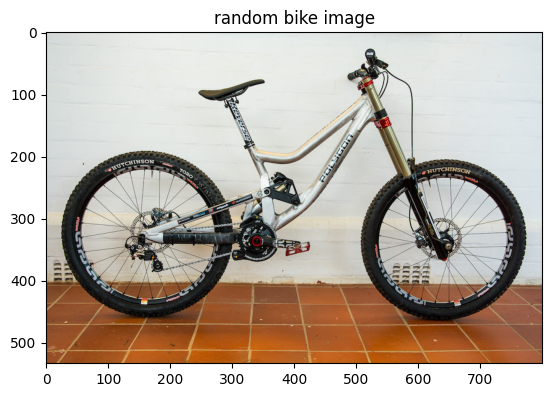

In [ ]:
# ------------------------Make a class the load pretrained weights of the CNN------------------------------------------------
num_of_classes = 1000
model = AlexNet(num_of_classes)
model.to(device)

# ------------------------Read an image using PIL------------------------------------------------
img_index       = 1
img_name        = TEST_IMAGE_DIR + '/' + image_name_list[img_index]
img = PIL.Image.open(img_name)
plt.imshow(img)
plt.title("random bike image")

# ------------------------Transform the image by resizing + normalizing -------------------------
imagenet_mean, imagenet_std = get_imagenet_mean_std_normalized()
my_transform = transforms.Compose(
    [ transforms.Resize( (227, 227) ),
      transforms.ToTensor(),
      transforms.Normalize(mean=imagenet_mean, std=imagenet_std)]
)
img_transformed = my_transform(img).unsqueeze(0).to(device)
print(f"input image.shape={img_transformed.shape}")

# --------------------------------------------------------------------
model.eval()
raw_output = model(img_transformed)
output_prob = torch.softmax( raw_output, dim=1 )
display_prediction(output_prob, label_map, how_many=7)

#**Group Activity#1**
> **Task#1**
- Modify the AlexNet network architecture by updating the last layer's structure and replace the pretrained weights of the last layer with new random weights.
- Apply a different image from the above list and see the result.


In [ ]:
import torch
import torch.nn as nn
from torchvision import models
import pdb

# You can give any name to your new network, e.g., AlexNet.
# You should load the pretrained AlexNet model from torchvision.models.
# This model was trained on over a million real-world images from ImageNet.


class AlexNet(nn.Module):

    def __init__(self, num_classes, pretrained=True):

        super(AlexNet, self).__init__()

        # download PyTorch's own implementation of AlexNet model trained on ImageNet dataset
        net             = models.alexnet(pretrained=True)


        # retained weightes for convolutional, pooling, linear layers from AlexNet
        self.features   = net.features
        self.avgpool    = net.avgpool
        self.classifier = net.classifier

        # -----------------------MODIFICATION-------------------------------------
        # IMPORTANT: If you need to fine-tune this network for your own dataset,
        # the simplest modification is to replace the last layer in self.classifier with
        # the updated AlexNet has the desired number of output classes: 'num_classes'
        self.classifier[-1] = nn.Linear(4096, num_classes) # only this last layer's weights will be trained from scratch
        # ------------------------------------------------------------------------


    def forward(self, x):

        print("shape of input: ", x.shape)
        x = self.features(x)
        print("output shape (self.features): ", x.shape)
        x = self.avgpool(x)
        print("output shape (self.avgpool): ", x.shape)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        print("output shape (self.classifier): ", x.shape)
        return x


> ### **Task 2: Run the pretrained model on a random image (you can download one from the internet or use an image from your laptop) to evaluate its classification performance.**

>

> Essentially, repeat the experiment we did earlier.


In [ ]:
# your code
# ...
# ...
# ...

> ### **Task 3: Summarize your observations and discuss them with your group members.**

>> Do you notice anything unusual, or does everything seem normal?

>> Explain your reasoning.


##**your answer**

# ...
# ...
# ...

<!--
import json
import numpy as np

def load_json_file(file_path):

  data = {}
  with open(file_path, 'r') as file:
    data = json.load(file)

  return data

def write_json_file(file_path):

  data = {}
  with open(file_path, 'w') as file:
    data = json.dump(data, file)

  return data

file_path         = '/content/drive/MyDrive/cs181_fall26/module_3_classification/imagenet_1000_classes.json'
label_map         = load_json_file(file_path)
print(label_map)
-->